# ECMWF GRIB2 Forecast Explorer

This notebook loads `.grib2` forecast files downloaded from ECMWF operational forecasts  
and provides a quick interface to:

- List all available variables in the file
- Extract and plot selected variables (e.g., temperature, wind, radiation)
- Convert raw data to Celsius if needed
- Clip to a region (e.g., Bhutan)

To begin, update the file path to point to one of your downloaded GRIB2 files.


In [1]:
import pygrib
import matplotlib.pyplot as plt
import os

In [2]:
save_dir = "../../ecmwf_forecasts/"
output_path = os.path.join(save_dir, "20250730000000-0h-oper-fc.grib2")
grbs = pygrib.open(output_path)

variable_names = list(set(grb.name for grb in grbs))
variable_names.sort()

print(f"Total variables found: {len(variable_names)}")
for name in variable_names:
    print("-", name)

Total variables found: 46
- 10 metre U wind component
- 10 metre V wind component
- 100 metre U wind component
- 100 metre V wind component
- 2 metre dewpoint temperature
- 2 metre temperature
- Divergence
- Eastward surface sea water velocity
- Geopotential
- Geopotential height
- Land-sea mask
- Maximum 10 metre wind gust since previous post-processing
- Maximum temperature at 2 metres in the last 3 hours
- Mean sea level pressure
- Minimum temperature at 2 metres in the last 3 hours
- Most-unstable CAPE
- Northward surface sea water velocity
- Precipitation type
- Relative humidity
- Runoff
- Sea ice thickness
- Sea surface height
- Skin temperature
- Slope of sub-gridscale orography
- Snow albedo
- Soil temperature
- Specific humidity
- Standard deviation of sub-gridscale orography
- Surface long-wave (thermal) radiation downwards
- Surface net long-wave (thermal) radiation
- Surface net short-wave (solar) radiation
- Surface pressure
- Surface short-wave (solar) radiation downward

In [3]:
gust = grbs.select(name='Temperature')[0]
data, lats, lons = gust.data()
print("Shape:", data.shape)

Shape: (721, 1440)


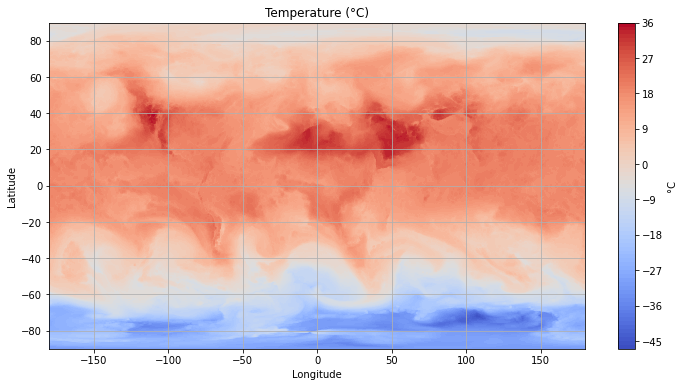

In [4]:
# Optional: Convert from Kelvin to Celsius
data_celsius = data - 273.15

# Plot
plt.figure(figsize=(12, 6))
plt.contourf(lons, lats, data_celsius, levels=100, cmap='coolwarm')
plt.title("Temperature (°C)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label="°C")
plt.grid(True)
plt.show()